In [1]:
import mujoco
import mediapy as media

# Iterating to build bike in xml

## start by playing aroudn with the wheel 

### Make a basic wheel via ellipsoid

""

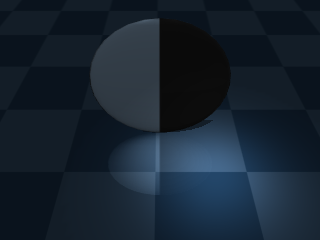

In [2]:
model = mujoco.MjModel.from_xml_path('bike_models/wheel.xml')
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)
    media.show_image(renderer.render())

### Play around with inertial properties and inital velocitys

#### Set initial velocities

In [3]:
model = mujoco.MjModel.from_xml_path('bike_models/wheel.xml')
data = mujoco.MjData(model)

duration = 2 # seconds
framerate = 30 # Hz
frames = []

# set the initial state
mujoco.mj_resetData(model,data)
data.joint('root').qvel = [1, 0, 0, 0, 1, 0]

with mujoco.Renderer(model) as renderer:
    while data.time < duration:
        mujoco.mj_step(model, data)
        # mujoco.mj_forward(model, data) ??? mj step vs mj_forward ???
        if len(frames) < data.time * framerate:
           renderer.update_scene(data)
           pixels = renderer.render()
           frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


#### build a setup to play with inertias

In [95]:
model = mujoco.MjModel.from_xml_path('bike_models/wheels.xml')
data = mujoco.MjData(model)
height = 480
width = 1280

duration = 2 # seconds
framerate = 30 # Hz
frames = []

# set the initial state
mujoco.mj_resetData(model,data)
data.joint('root1').qvel = [0, 0, 0, 0, 1, 0]
data.joint('root2').qvel = [0, 0, 0, 0, 1, 0]
data.joint('root3').qvel = [0, 0, 0, 0, 1, 0]

with mujoco.Renderer(model, height, width) as renderer:
    # # mujoco.mj_step(model, data)
    # mujoco.mj_forward(model, data)# ??? mj step vs mj_forward ???
    # renderer.update_scene(data, camera='top')
    # pixels = renderer.render()
    # frames.append(pixels)
    while data.time < duration:
        mujoco.mj_step(model, data)
        # mujoco.mj_forward(model, data) ??? mj step vs mj_forward ???
        if len(frames) < data.time * framerate:
           renderer.update_scene(data, camera='top')
           pixels = renderer.render()
           frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


#### Play with inertias

In [118]:
# Approximate inertias based on diameter, mass and thickness of a wheel
thickness = .03 # meters
diameter1 = 0.74 # meters
diameter2 = 0.68 # meters
mass = 2.0 # kg

# Inertia of a hoop
I1_hoop = mass*(diameter1/2)**2
I2_hoop = 0.5*mass*(diameter1/2)**2

# Inertia of a ring
I1_ring = 0.5*mass*((diameter1/2)**2 +(diameter2/2)**2)
I2_ring = 2/3*mass*(((diameter1/2+diameter2/2)/2)**2)

# Inertia of a cylinder
I1_disk = 0.5*mass*(diameter1/2)**2
I2_disk = 1/4*mass*(diameter1/2)**2 + 1/12*mass*thickness**2

# print all the inertias
print(f'I2 I1 I2 hoop = {I2_hoop} {I1_hoop} {I2_hoop}')
print(f'I2 I1 I2 ring = {I2_ring} {I1_ring} {I2_ring}')
print(f'I2 I1 I2 disk = {I2_disk} {I1_disk} {I2_disk}')


I2 I1 I2 hoop = 0.1369 0.2738 0.1369
I2 I1 I2 ring = 0.1680333333333333 0.2525 0.1680333333333333
I2 I1 I2 disk = 0.0686 0.1369 0.0686


In [179]:
model = mujoco.MjModel.from_xml_path('bike_models/wheels.xml')
data = mujoco.MjData(model)
height = 480
width = 1280

duration = 3 # seconds
framerate = 30 # Hz
frames = []

# set the initial state
mujoco.mj_resetData(model,data)
data.joint('root1').qvel = [0, 0, 0, 0, .1, 0]
data.joint('root2').qvel = [0, 0, 0, 0, .1, 0]
data.joint('root3').qvel = [0, 0, 0, 0, .1, 0]
data.joint('root4').qvel = [0, 0, 0, 0, .1, 0]

with mujoco.Renderer(model, height, width) as renderer:
    while data.time < duration:
        mujoco.mj_step(model, data)
        # mujoco.mj_forward(model, data)# ??? mj step vs mj_forward ???
        if len(frames) < data.time * framerate:
           renderer.update_scene(data, camera='top')
           pixels = renderer.render()
           frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


### Put two wheels together on a frame no steering

#### build a no frills DH frame

""

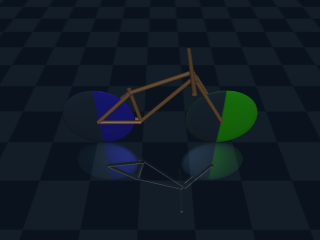

In [177]:
model = mujoco.MjModel.from_xml_path('bike_models/frame.xml')
data = mujoco.MjData(model)

with mujoco.Renderer(model) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)
    media.show_image(renderer.render())

#### Initial velocity test
given an initial velocity test it should roll straight just like the wheels
given a slight purturbance in the y axis it should fall right over


In [ ]:
model = mujoco.MjModel.from_xml_path('bike_models/frame.xml')
data = mujoco.MjData(model)

duration = 2 # seconds
framerate = 30 # Hz
frames = []

# set the initial state
mujoco.mj_resetData(model, data)
data.joint('root').qvel = [1, 0 ,0, 0, 0, 0]
# set the state of the wheels???

with mujoco.Renderer(model) as renderer:
    while data.time < duration:
        mujoco.mj_step(model, data)
        

# Tools

In [4]:
import os

# Path
path = 'bike_models/wheel.xml'

# Check if its a file
if os.path.isfile(path):
    print("File exists.")
else:
    print("File does not exist.")
# Check if the directory exists
if os.path.isdir(path):
    print("Directory exists. Listing contents:")
    for item in os.listdir(path):
        print(item)
else:
    print("Directory does not exist.")

File exists.
Directory does not exist.
